In [546]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

### Loading Dataset

In [547]:
wine_data = pd.read_csv('wine_quality.csv')

### Check how the data is distributed

In [548]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Information about the data columns

In [549]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [550]:
wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

### How the data columns are distributed?

### Distribution of quality labels

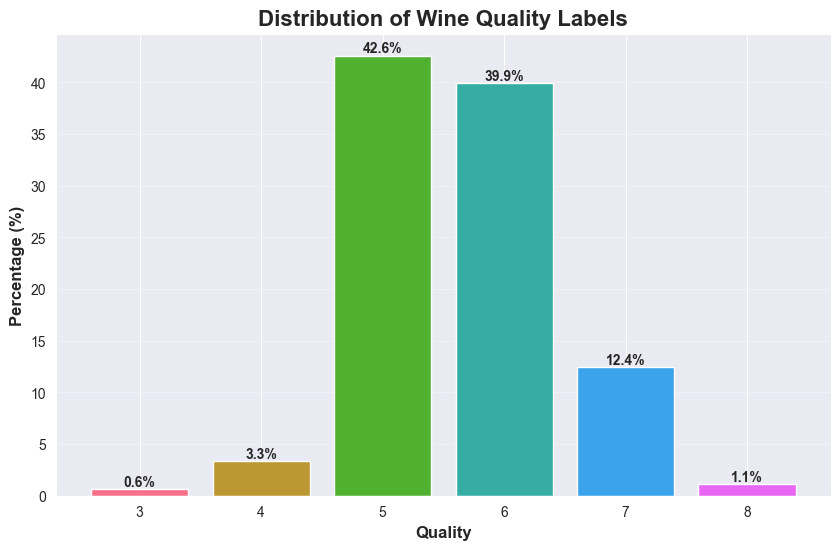

In [551]:
quality_counts = wine_data['quality'].value_counts().sort_index()

quality_percentages = (quality_counts / quality_counts.sum()) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(quality_percentages.index, quality_percentages.values, 
               color=sns.color_palette('husl', len(quality_percentages)))

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Wine Quality Labels', fontsize=16, fontweight='bold')
plt.xticks(quality_percentages.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='quality', ylabel='fixed acidity'>

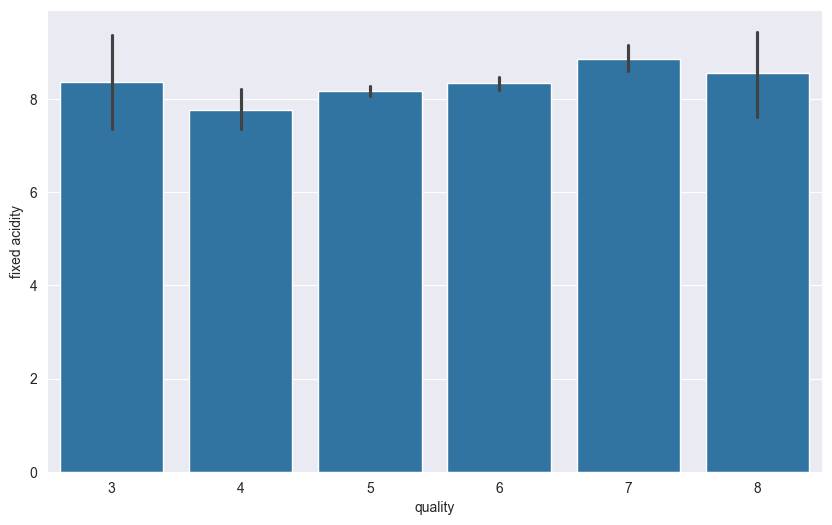

In [552]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'fixed acidity', data = wine_data)


`Fixed acity does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='volatile acidity'>

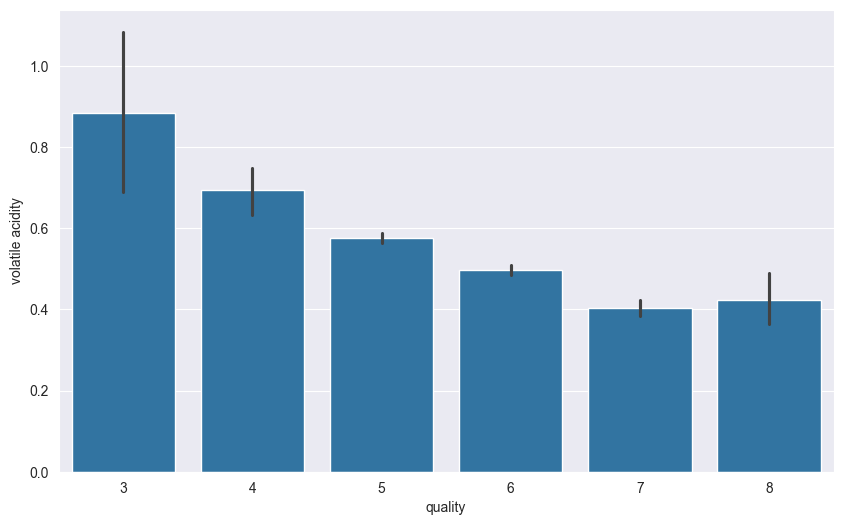

In [553]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_data)


`Quite a downing trend in the volatile acidy as we go higher the quality`

<Axes: xlabel='quality', ylabel='citric acid'>

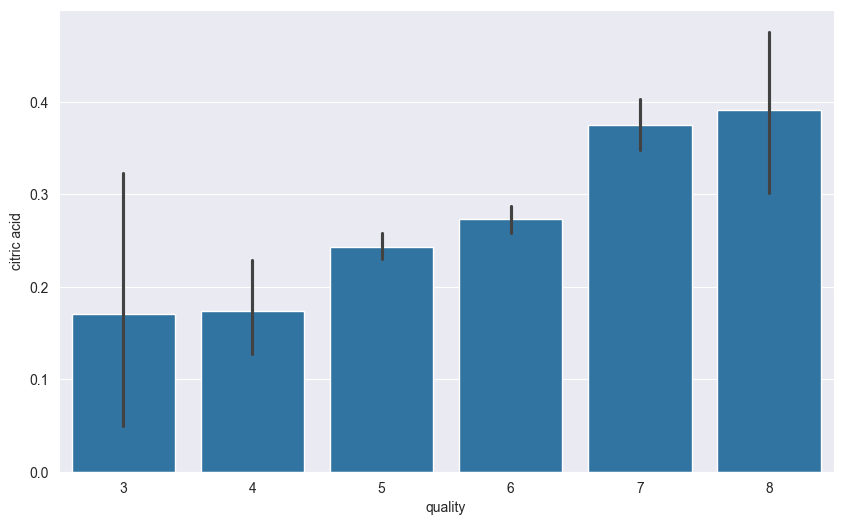

In [554]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_data)


`Citric acid go higher as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='residual sugar'>

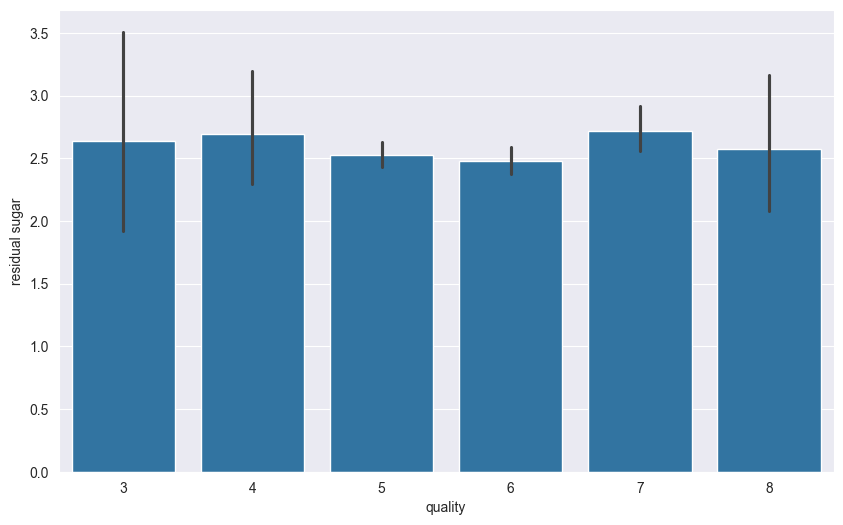

In [555]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine_data)


`Residual sugar does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='chlorides'>

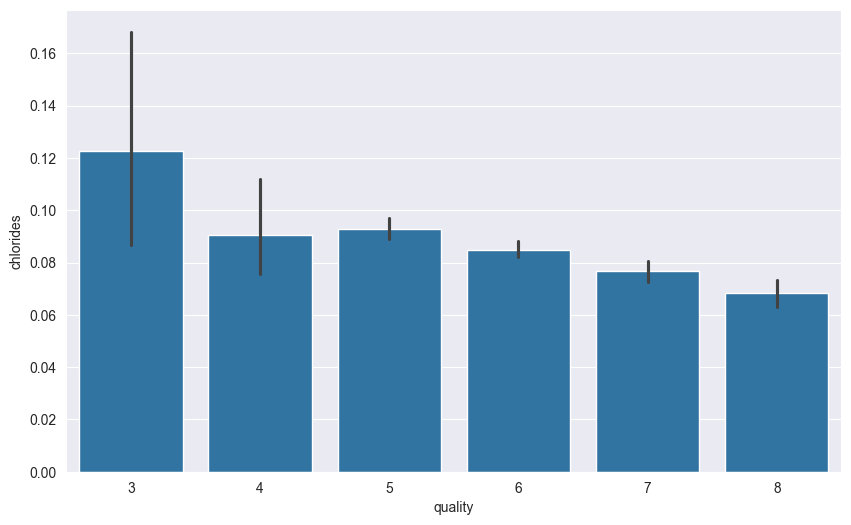

In [556]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'chlorides', data = wine_data)


`Composition of chloride also go down as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

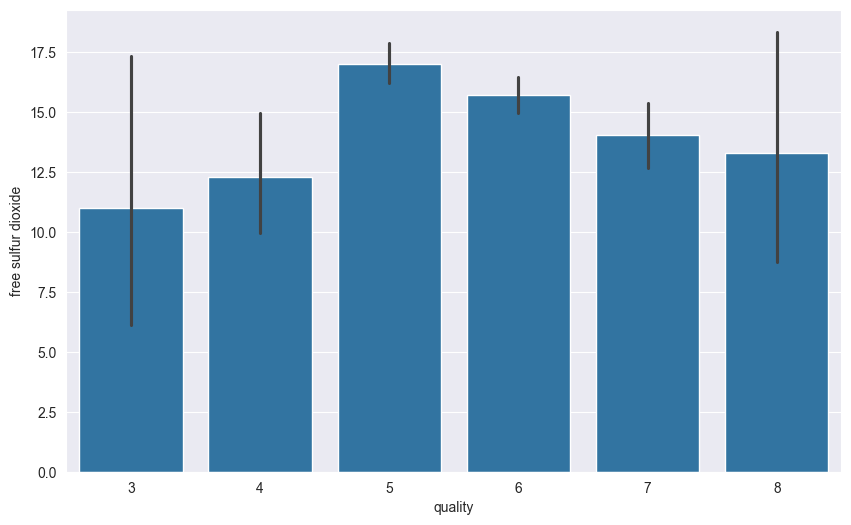

In [557]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

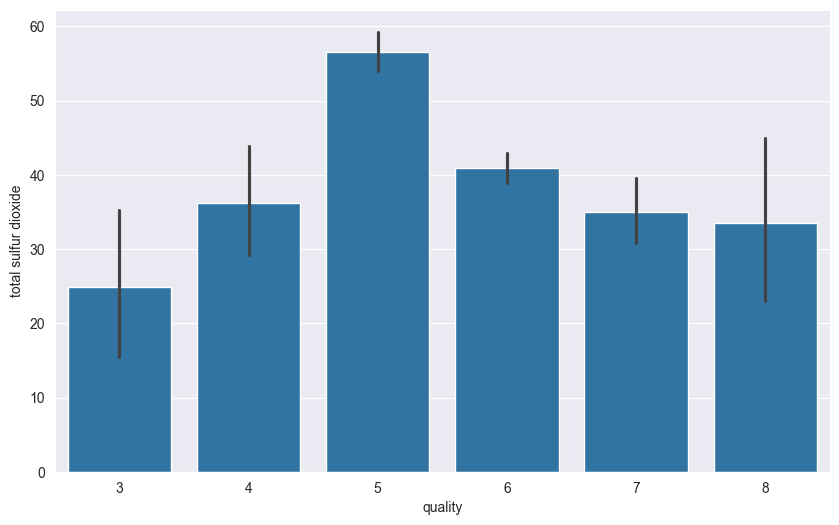

In [558]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'total sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='density'>

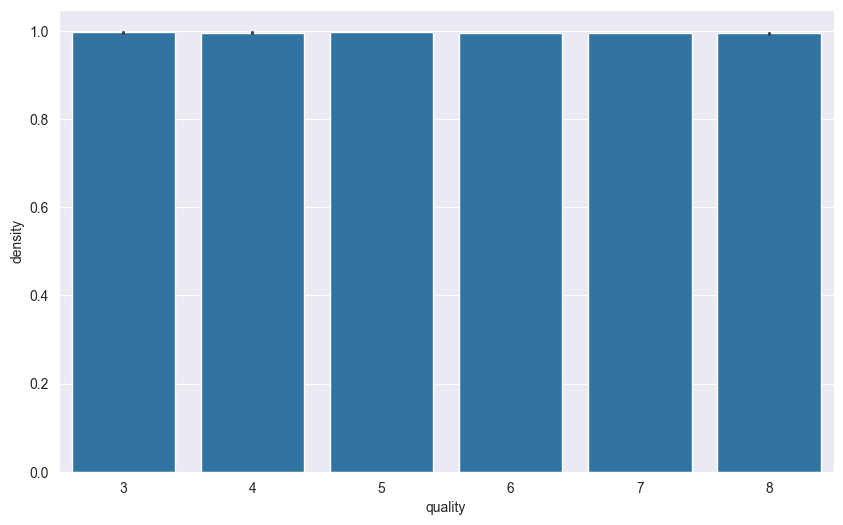

In [559]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'density', data = wine_data)


<Axes: xlabel='quality', ylabel='pH'>

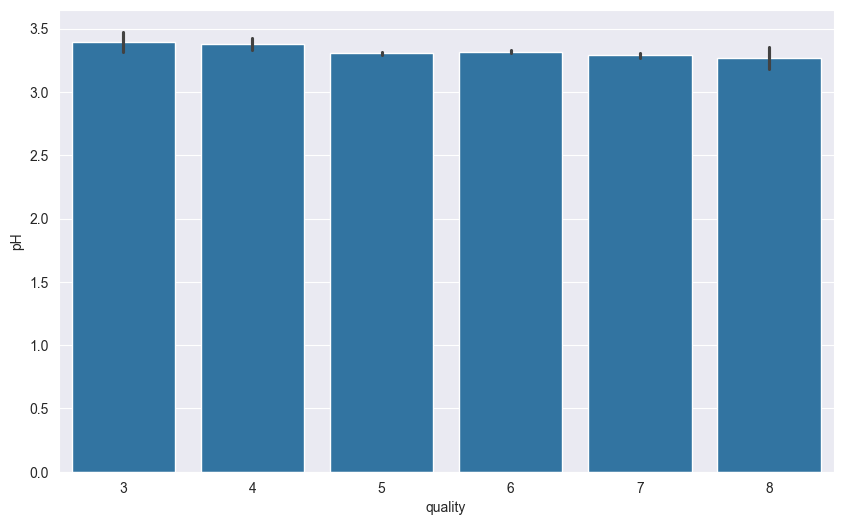

In [560]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'pH', data = wine_data)


<Axes: xlabel='quality', ylabel='sulphates'>

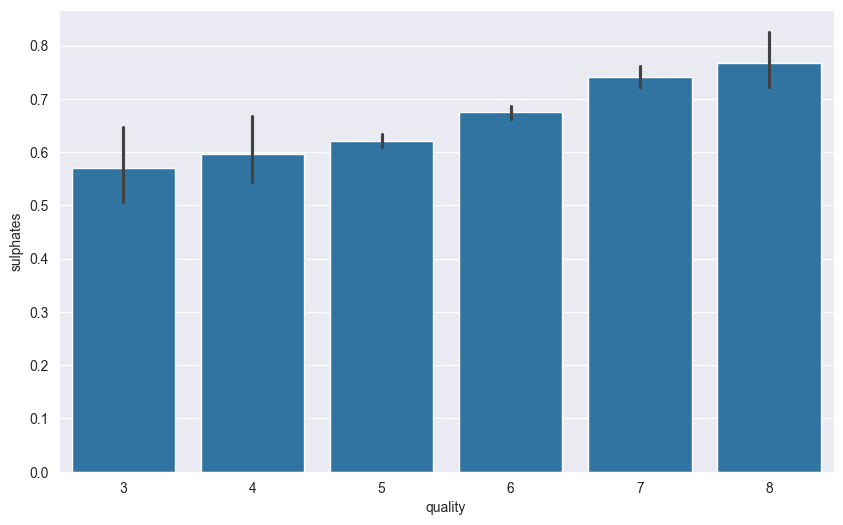

In [561]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'sulphates', data = wine_data)


`Sulphates level goes higher with the quality of wine`

<Axes: xlabel='quality', ylabel='alcohol'>

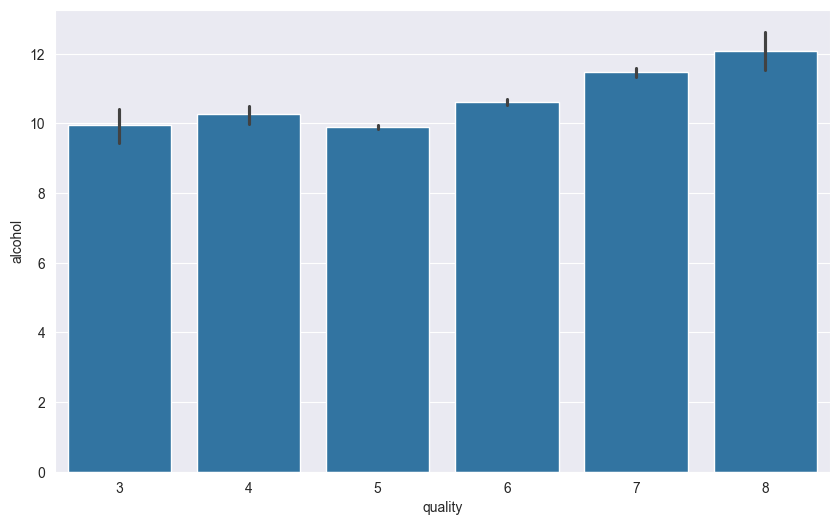

In [562]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine_data)


`Alcohol level also goes higher as te quality of wine increases`

## Missing values e linhas duplicadas

In [563]:
print("Missing values por coluna:\n")
print(wine_data.isna().sum())

print("\nTotal de missing values no dataset:", wine_data.isna().sum().sum())

print("\nTotal de linhas duplicadas:")
print(wine_data.duplicated().sum())

#apagar duplicados
wine_data = wine_data.drop_duplicates()







Missing values por coluna:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de missing values no dataset: 0

Total de linhas duplicadas:
240


In [564]:
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


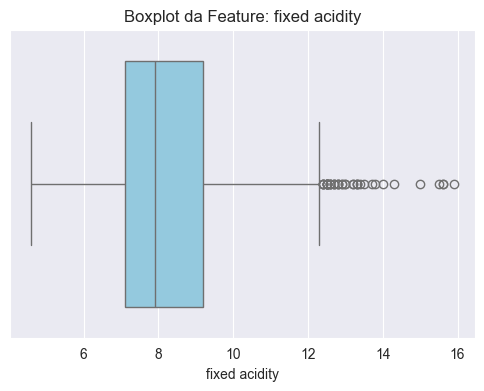

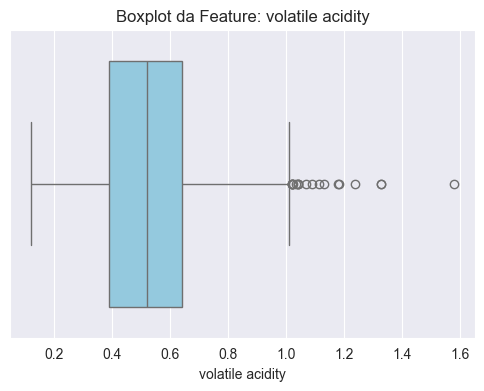

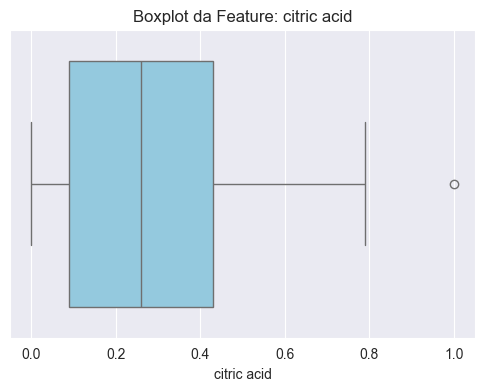

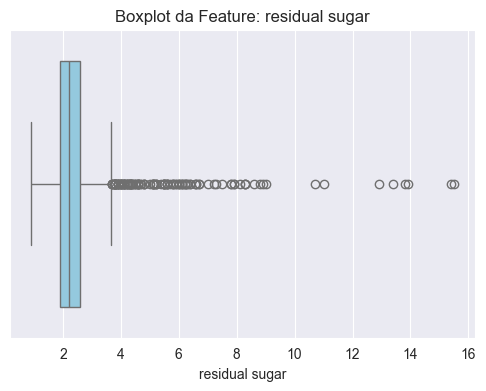

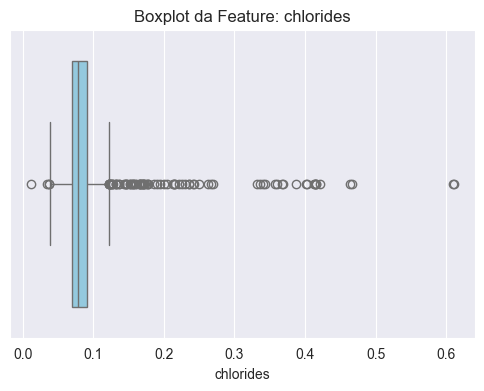

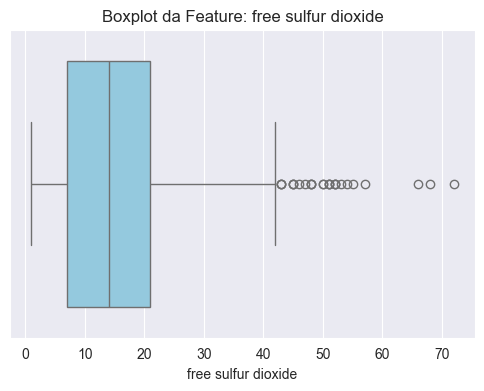

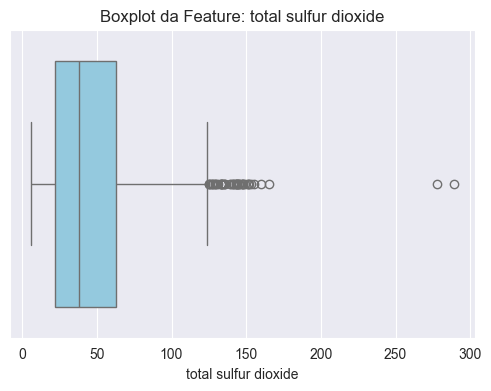

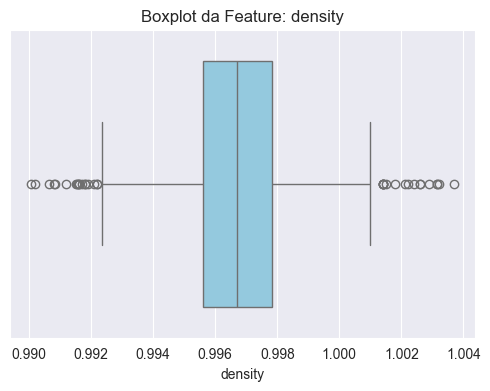

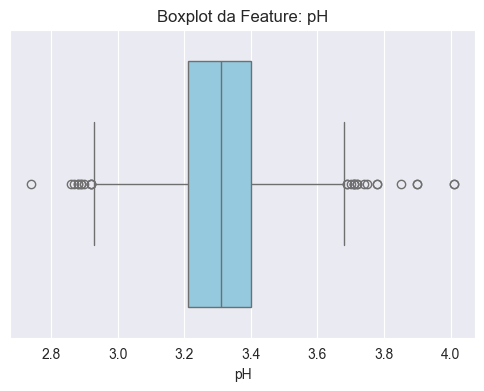

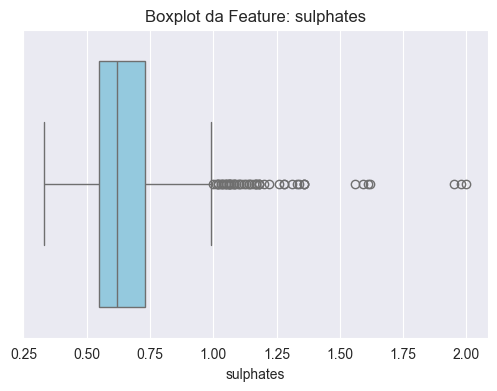

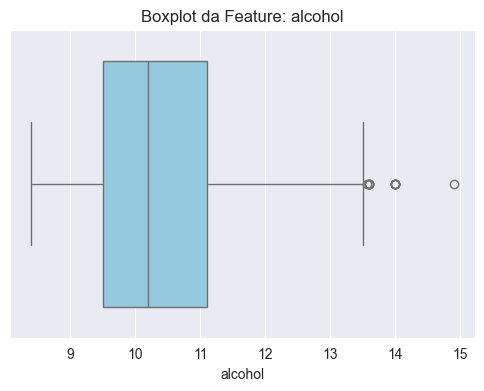

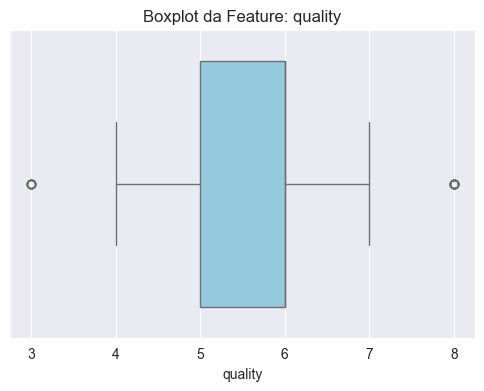

In [565]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in wine_data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=wine_data[col], color='skyblue')
    plt.title(f"Boxplot da Feature: {col}")
    plt.xlabel(col)
    plt.show()



In [566]:
import pandas as pd
import numpy as np

outlier_summary = []

for col in wine_data.columns:
    if wine_data[col].dtype != 'object':  # só colunas numéricas

        Q1 = wine_data[col].quantile(0.25)
        Q3 = wine_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # mascara para outliers
        outliers = wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]
        num_outliers = outliers.shape[0]
        total = wine_data.shape[0]
        perc_outliers = (num_outliers / total) * 100

        outlier_summary.append([col, num_outliers, total, perc_outliers])

# Criar DataFrame final
outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature", "Nº Outliers", "Total", "Percentagem (%)"])

# Ordenar da variável com mais outliers para a com menos
outlier_df = outlier_df.sort_values(by="Percentagem (%)", ascending=False)

outlier_df


,Feature,Nº Outliers,Total,Percentagem (%)
3,residual sugar,126,1359,9.271523
4,chlorides,87,1359,6.401766
9,sulphates,55,1359,4.047093
6,total sulfur dioxide,45,1359,3.311258
0,fixed acidity,41,1359,3.016924
7,density,35,1359,2.575423
8,pH,28,1359,2.060338
11,quality,27,1359,1.986755
5,free sulfur dioxide,26,1359,1.913171
1,volatile acidity,19,1359,1.398087


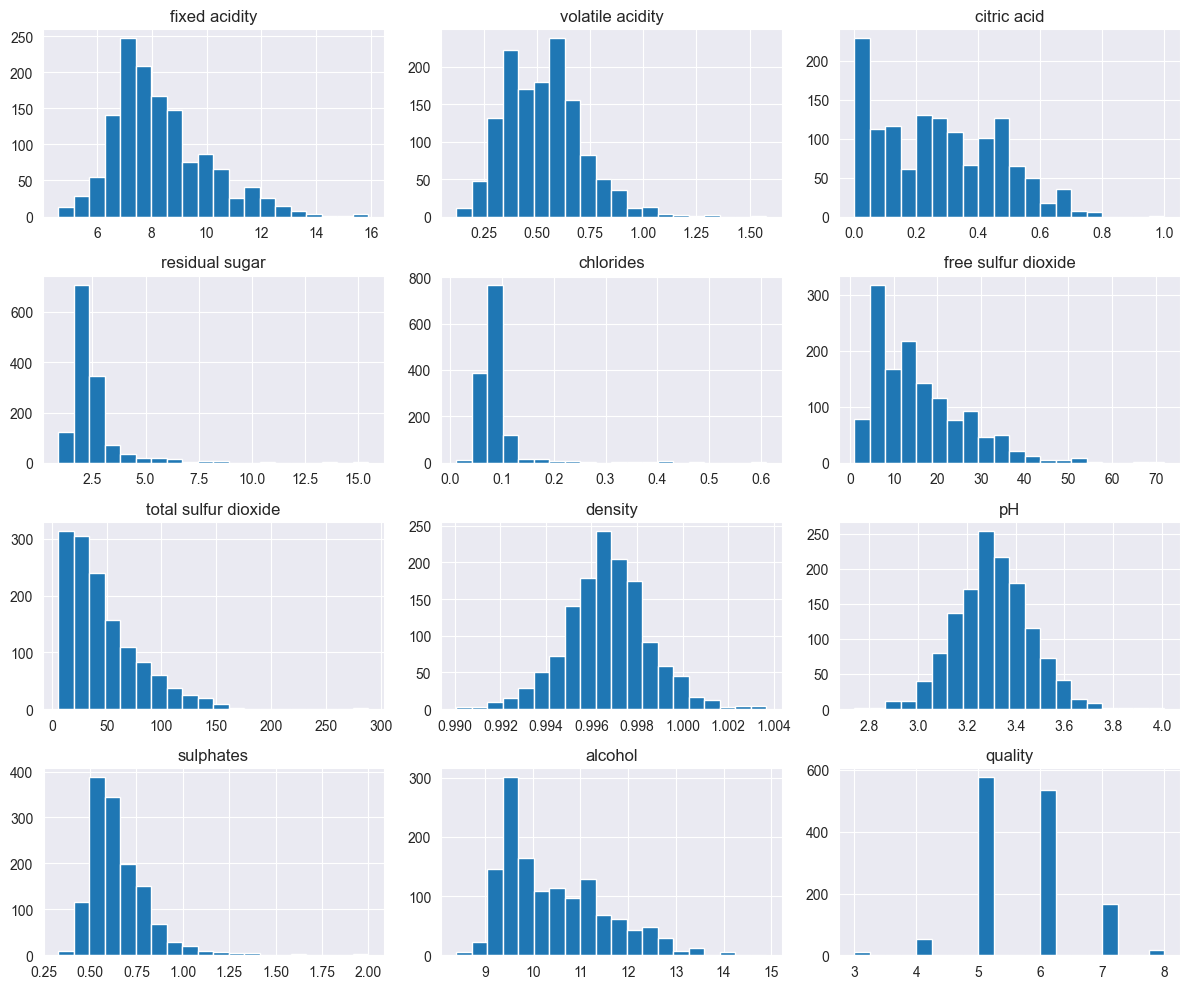

In [567]:
wine_data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


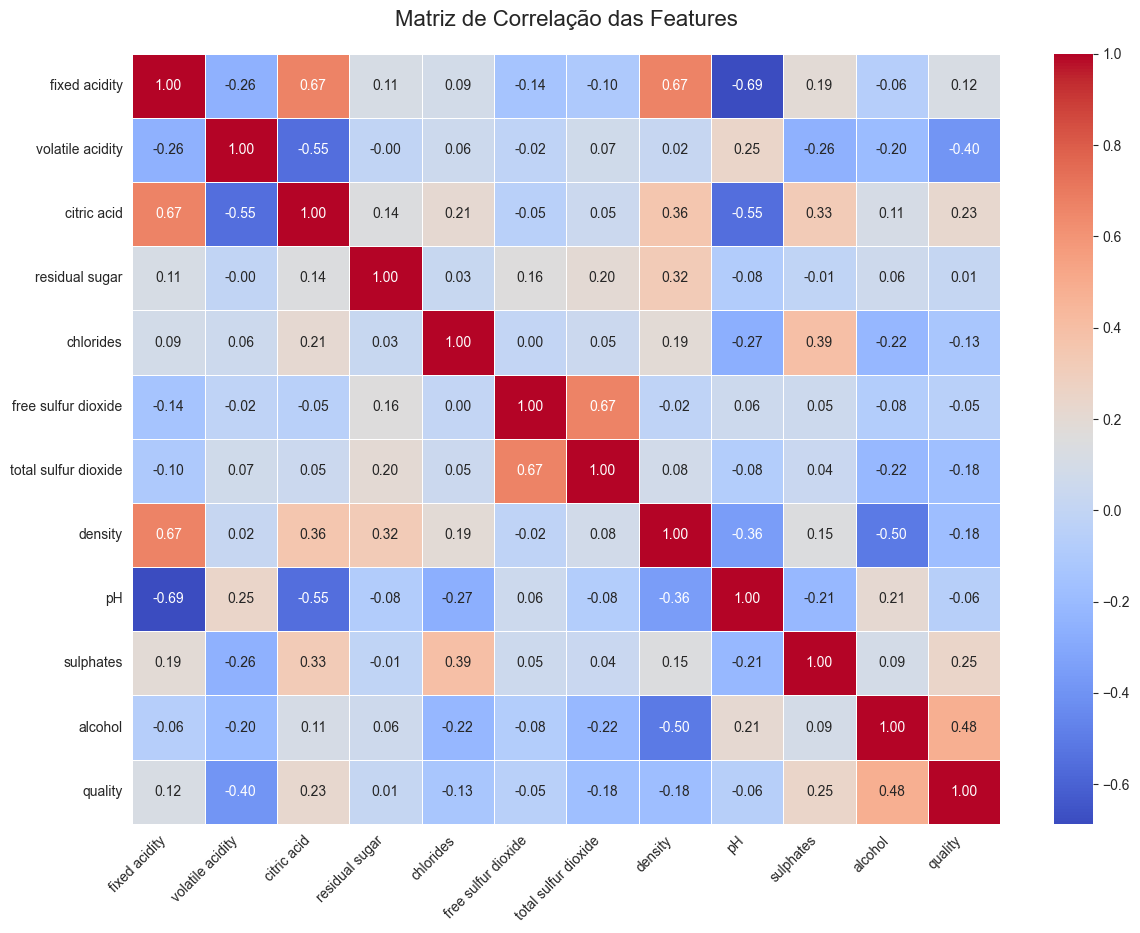

In [568]:
plt.figure(figsize=(14,10))

sns.heatmap(
    wine_data.corr(),
    annot=True,            # mostra valores
    fmt=".2f",             # 2 casas decimais
    cmap="coolwarm",       # mapa de cores perceptível
    linewidths=0.5,        # linhas entre células
    annot_kws={"size": 10} # tamanho do texto
)

plt.title("Matriz de Correlação das Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()



In [569]:
wine_data.corr()['quality'].sort_values(ascending=False)


quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

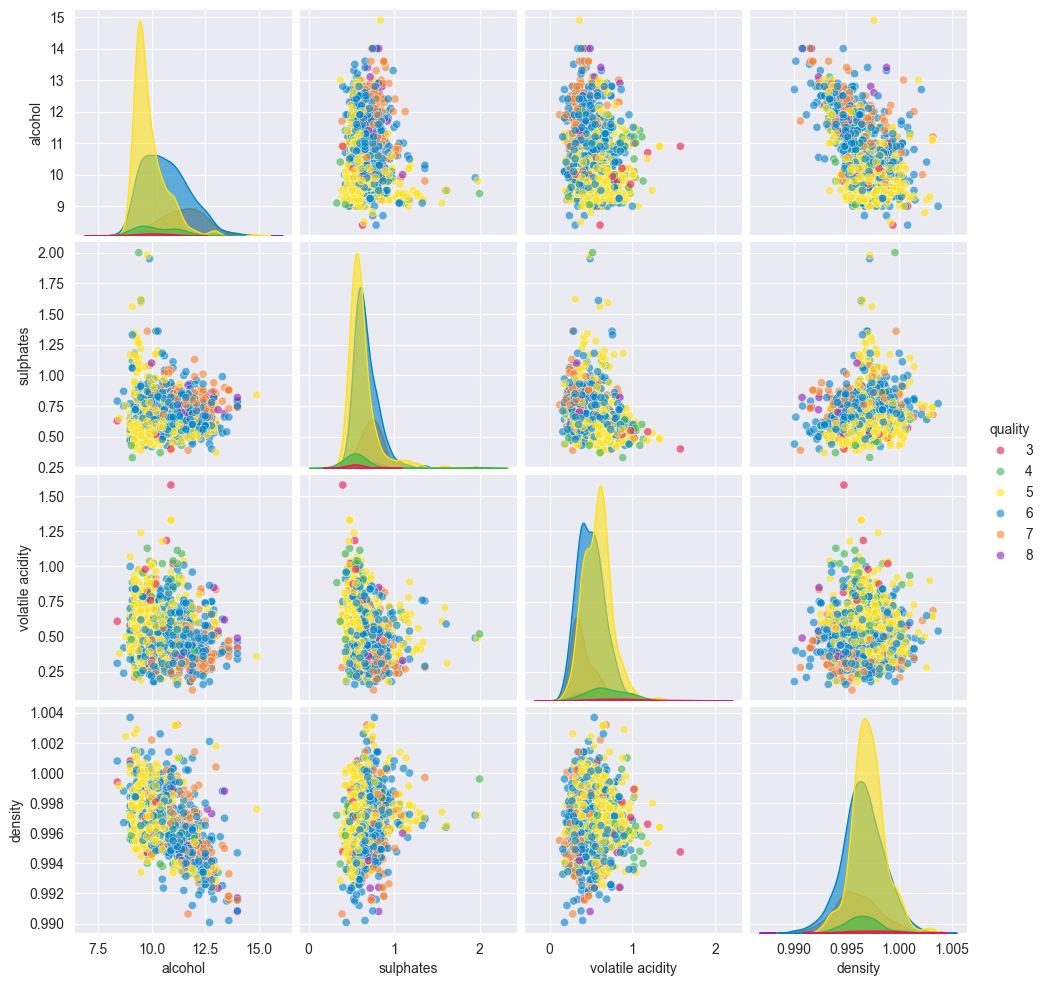

In [570]:
top_corr = ['alcohol', 'sulphates', 'volatile acidity', 'density', 'quality']
custom_palette = {
    3: '#e6194b',  # red
    4: '#3cb44b',  # green
    5: '#ffe119',  # yellow
    6: '#0082c8',  # blue
    7: '#f58231',  # orange
    8: '#911eb4'   # purple
}

sns.pairplot(
    wine_data[top_corr],
    hue='quality',
    palette=custom_palette,
    plot_kws={'alpha':0.6, 's':35},
    diag_kws={'alpha':0.6}
)





## process data

In [571]:
wine_data_bi=wine_data.copy()

# 1. Criar a classificação binária baseada na regra:
# quality <= 5 -> 'under-average'
# quality >= 6 -> 'above-average'
wine_data_bi['Target'] = wine_data_bi['quality'].apply(lambda x: 1 if x >= 6 else 0)

wine_data_bi=wine_data_bi.drop(columns=['quality'])

wine_data_bi.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


## Correlação da variavel binaria Target

In [572]:
wine_data_bi.corr()['Target'].sort_values(ascending=False)


Target                  1.000000
alcohol                 0.446176
sulphates               0.211365
citric acid             0.167903
fixed acidity           0.091761
pH                      0.004693
residual sugar         -0.002371
free sulfur dioxide    -0.069207
chlorides              -0.115071
density                -0.168958
total sulfur dioxide   -0.235046
volatile acidity       -0.327195
Name: Target, dtype: float64

In [573]:
wine_data_bi["Target"].value_counts()


Target
1    719
0    640
Name: count, dtype: int64

## Classificaçao binaria


## Com todas as features

Separar X e y

In [574]:
X = wine_data_bi.drop(columns=['Target'])
y = wine_data_bi['Target']


Train/Test Split (75/25 + stratify + random_state=42)


In [575]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


Normalização (StandardScaler)

In [576]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

NEURAL NETWORK – Modelo Base (MLPClassifier)

In [577]:

# Modelo base da Neural Network
nn_clf = MLPClassifier(
    hidden_layer_sizes=(64,32),   # duas camadas escondidas
    activation='relu',            # recomendada
    solver='adam',                # bom para datasets médios
    alpha=0.0001,                 # regularização leve
    learning_rate='adaptive',     # ajusta automaticamente
    max_iter=600,                 # garante convergência
    random_state=42

    #hidden_layer_sizes=(1, ),
    #max_iter=100,
    #tol=0.01,
    #random_state=42
)

# Treinar com os dados normalizados
nn_clf.fit(X_train_scaled, y_train)


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,600
,shuffle,True
,random_state,42


Fazer previsões

In [578]:
nn_preds = nn_clf.predict(X_test_scaled)


Avaliação rápida

In [579]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Neural Network (MLPClassifier) ===")
print(classification_report(y_test, nn_preds))
print(confusion_matrix(y_test, nn_preds))


=== Neural Network (MLPClassifier) ===
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       160
           1       0.76      0.70      0.73       180

    accuracy                           0.73       340
   macro avg       0.73      0.73      0.73       340
weighted avg       0.73      0.73      0.73       340

[[121  39]
 [ 54 126]]


In [580]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nn_accuracy = accuracy_score(y_test, nn_preds)
nn_precision = precision_score(y_test, nn_preds)
nn_recall = recall_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds)

print("=== Neural Network (MLPClassifier) – Métricas Detalhadas ===")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1 Score:  {nn_f1:.4f}")


=== Neural Network (MLPClassifier) – Métricas Detalhadas ===
Accuracy:  0.7265
Precision: 0.7636
Recall:    0.7000
F1 Score:  0.7304
